## Network Sience

In [1]:
pip install networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 16.3 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Create an empty graph
G = nx.Graph()

# Add nodes
#G.add_node("A")
#G.add_node("B")
#G.add_node("C")
#G.add_node("D")
#G.add_node("E")
#G.add_node("F")
#G.add_node("G")
#G.add_node("H")

G.add_edge("A", "B", weight=0.6)
G.add_edge("A", "F", weight=0.6)
G.add_edge("A", "H", weight=0.6)
G.add_edge("A", "C", weight=0.2)
G.add_edge("I", "F", weight=0.1)
G.add_edge("B", "D", weight=0.6)
G.add_edge("C", "E", weight=0.7)
G.add_edge("C", "F", weight=0.4)
G.add_edge("A", "D", weight=0.3)
G.add_edge("G", "H", weight=0.5)
G.add_edge("G", "C", weight=0.7)
G.add_edge("B", "H", weight=0.4)
G.add_edge("D", "I", weight=0.6)
G.add_edge("D", "J", weight=0.4)
G.add_edge("B", "J", weight=0.4)

In [4]:
G.nodes()

NodeView(('A', 'B', 'F', 'H', 'C', 'I', 'D', 'E', 'G', 'J'))

In [5]:
G.edges()

EdgeView([('A', 'B'), ('A', 'F'), ('A', 'H'), ('A', 'C'), ('A', 'D'), ('B', 'D'), ('B', 'H'), ('B', 'J'), ('F', 'I'), ('F', 'C'), ('H', 'G'), ('C', 'E'), ('C', 'G'), ('I', 'D'), ('D', 'J')])

In [12]:
G.edges(data=True)

EdgeDataView([('A', 'B', {'weight': 0.6}), ('A', 'F', {'weight': 0.6}), ('A', 'H', {'weight': 0.6}), ('A', 'C', {'weight': 0.2}), ('A', 'D', {'weight': 0.3}), ('B', 'D', {'weight': 0.6}), ('B', 'H', {'weight': 0.4}), ('B', 'J', {'weight': 0.4}), ('F', 'I', {'weight': 0.1}), ('F', 'C', {'weight': 0.4}), ('H', 'G', {'weight': 0.5}), ('C', 'E', {'weight': 0.7}), ('C', 'G', {'weight': 0.7}), ('I', 'D', {'weight': 0.6}), ('D', 'J', {'weight': 0.4})])

In [17]:
G.degree()

DegreeView({'A': 5, 'B': 4, 'F': 3, 'H': 3, 'C': 4, 'I': 2, 'D': 4, 'E': 1, 'G': 2, 'J': 2})

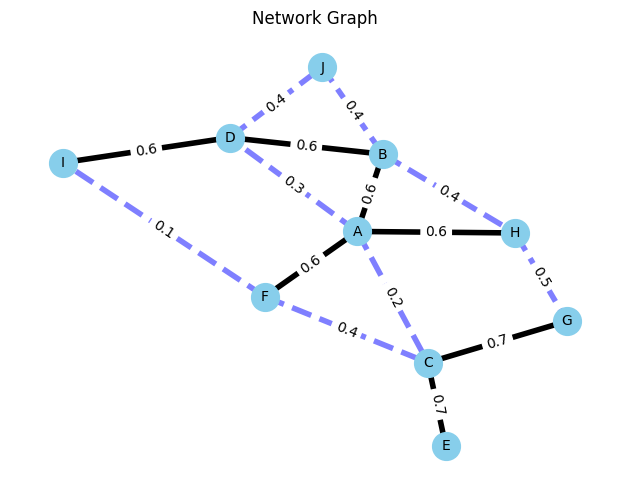

<Figure size 800x600 with 0 Axes>

In [15]:
elarge = [(u, v) for (u, v, d) in G.edges(data=True) if d["weight"] > 0.5]
esmall = [(u, v) for (u, v, d) in G.edges(data=True) if d["weight"] <= 0.5]

pos = nx.spring_layout(G, seed=5)  # positions for all nodes - seed for reproducibility

# nodes
nx.draw_networkx_nodes(G, pos, node_size=400, node_color='skyblue')

# edges
nx.draw_networkx_edges(G, pos, edgelist=elarge, width=4)

nx.draw_networkx_edges(
    G, pos, edgelist=esmall, width=4, alpha=0.5, edge_color="b", style="dashed"
)

# node labels
nx.draw_networkx_labels(G, pos, font_size=10, font_family="sans-serif")
# edge weight labels
edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels)

# Draw the graph
plt.axis("off")
plt.tight_layout()
plt.title("Network Graph")
plt.figure(figsize=(8,6))
plt.show()

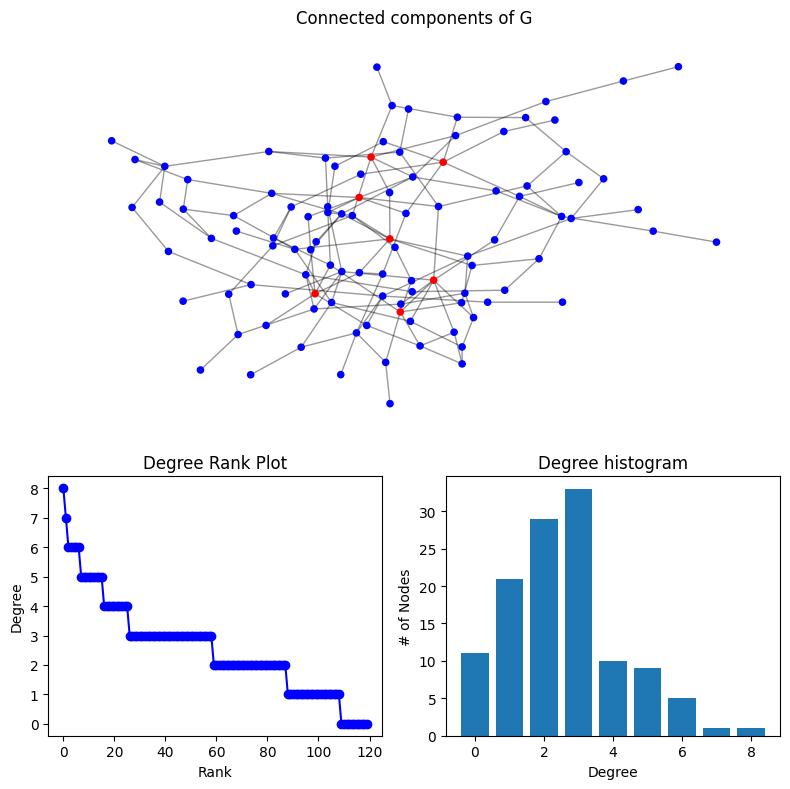

In [23]:
G = nx.gnp_random_graph(120, 0.02, seed=10374195)

degree_sequence = sorted((d for n, d in G.degree()), reverse=True)
dmax = max(degree_sequence)

fig = plt.figure("Degree of a random graph", figsize=(8, 8))

# Create a gridspec for adding subplots of different sizes
axgrid = fig.add_gridspec(5, 4)

ax0 = fig.add_subplot(axgrid[0:3, :])
Gcc = G.subgraph(sorted(nx.connected_components(G), key=len, reverse=True)[0])
pos = nx.spring_layout(Gcc, seed=10396953)

# Color list (red if nodes have degree more than or equal to 6, else blue)
node_red_blue = ["red" if G.degree[node] >= 6 else "blue" for node in Gcc.nodes]

# If you change the number to 8, you will see that there's only one node
# node_red_blue = ["red" if G.degree[node] >= 8 else "blue" for node in Gcc.nodes]

# nx.draw_networkx_nodes(Gcc, pos, ax=ax0, node_size=20)
nx.draw_networkx_nodes(Gcc, pos, ax=ax0, node_size=20, node_color=node_red_blue)
nx.draw_networkx_edges(Gcc, pos, ax=ax0, alpha=0.4)
ax0.set_title("Connected components of G")
ax0.set_axis_off()

ax1 = fig.add_subplot(axgrid[3:, :2])                   #location
ax1.plot(degree_sequence, "b-", marker="o")             #color and marker
ax1.set_title("Degree Rank Plot")
ax1.set_ylabel("Degree")
ax1.set_xlabel("Rank")                                  #Rank is like ranking where nodes with many edges win and takes high rank.

ax2 = fig.add_subplot(axgrid[3:, 2:])
ax2.bar(*np.unique(degree_sequence, return_counts=True))
ax2.set_title("Degree histogram")
ax2.set_xlabel("Degree")
ax2.set_ylabel("# of Nodes")

fig.tight_layout()
plt.show()

Rank(Node-Degree Rank): Order of the Nodes by the number of degree in descending order. Nodes with more degree will be have high ranking. Think of a competition where when you have winning score, then you have high ranking. In network science, nodes with many degree have high ranking.

Degree: The number of connection(edges) that a node has.

1. Upper graph: Plot of a network graph. The red colored nodes are the example of hubs(nodes with many connections). They can show the centrality in the relationships of network.

2. Lower Left: The rank-degree graph. You can see that the trend decrease drastically, meaning that there are only a few nodes with many edges, but there are more nodes as the degree decreases. 8-degree node is the least common. You can see that the 3-degree nodes are most common, with the length of the line.

3. Lower Right: This histogram shows the distribution of how many nodes are there by the number of the degree. 3-degree nodes are most common and 7,8-degree nodes are the least common.
